<a href="https://colab.research.google.com/github/sirnaet/Data-Wrangling/blob/main/Airplane_Crashes_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908.csv')

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
num_rows, num_cols = df.shape

print(f"The dataset has {num_rows} rows and {num_cols} columns.")

The dataset has 5268 rows and 13 columns.


In [ ]:
last_75 = df.tail(75)
display(last_75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


In [ ]:
#to determine the data types so as to establish the methid of handiling each column
print(df.dtypes)
#to print out the total number of missing values (NaN) for each column
print(df.isnull().sum())
#percentage of missing valuses per column
percentage_missing = (df.isnull().sum() / len(df)) * 100
print(percentage_missing.round(2))

Date             object
Time             object
Location         object
Operator         object
Flight #         object
Route            object
Type             object
Registration     object
cn/In            object
Aboard          float64
Fatalities      float64
Ground          float64
Summary          object
dtype: object
Date               0
Time            2219
Location          20
Operator          18
Flight #        4199
Route           1707
Type              27
Registration     335
cn/In           1228
Aboard            22
Fatalities        12
Ground            22
Summary          390
dtype: int64
Date             0.00
Time            42.12
Location         0.38
Operator         0.34
Flight #        79.71
Route           32.40
Type             0.51
Registration     6.36
cn/In           23.31
Aboard           0.42
Fatalities       0.23
Ground           0.42
Summary          7.40
dtype: float64


Justification for each column:
Time: Filling with placeholders such as 'Unknown'and 'Unrecorded'

Location: Drop the 20 rows that are missing because the number is negligible in relation to the size of the dataset

Operator: Fill it "Unknown" or Leave it as NaN because it's just a descriptive non-analytical column

Flight: As it is a meaningful column, in which the missingness does not affect the dataset as much, we can fill in the missing data with "Unknown"
Route: Use a placeholder and move on because it is just descriptive

Aboard: It is numeric and important and as only 27 rows have been affected, we can drop the rows in which it is missing

Fatalities: numerical float datatype that is a core varible, that is most analysed, hence since only 12 rows are affected, we can Drop the Rows.

Ground: Numeric with 0.42% missingness, and stands for number of deaths on the ground. The missing values therefore indicate no deaths on the ground, therefore we can fill in these values with 0 (zero)

Summary: it is a descriptive column that does not affect analysis therefore, we can use a place holder such as "Summary not available" or "Summary not found"


In [ ]:
fatality_locations = pd.DataFrame(df[['Date','Location','Aboard','Fatalities']])
fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


In [ ]:
#Highest number of fatalities
max_fatalities_row = fatality_locations.loc[fatality_locations['Fatalities'].idxmax()]
print(max_fatalities_row)

Date                        03/27/1977
Location      Tenerife, Canary Islands
Aboard                           644.0
Fatalities                       583.0
Name: 2963, dtype: object


In [ ]:
#Compare aboard vs fatalities directly in the raw dataframe
df ['Survivors'] = df['Aboard'] - df['Fatalities']

#crashes with 0 fatalities
no_fatalities = df[df['Fatalities'] == 0]
print(f"No. of crashes with zero fatalities: {len(no_fatalities)}")
no_fatalities[['Date', 'Location', 'Aboard', 'Fatalities'] ]

No. of crashes with zero fatalities: 58


,Date,Location,Aboard,Fatalities
108,10/21/1926,English Channel,12.0,0.0
387,03/05/1936,"Near Tengya, China",6.0,0.0
889,10/08/1947,"Near El Paso, Texas",54.0,0.0
897,11/11/1947,"Gallup, New Mexico",25.0,0.0
1265,05/25/1953,"Amsterdam, Netherlands",34.0,0.0
1359,01/19/1955,"Des Moines, Iowa",39.0,0.0
1440,09/09/1956,"Bartlesville, Oklahoma",18.0,0.0
1443,10/16/1956,Over the PacifiOcean,31.0,0.0
1610,06/30/1959,"Ishikawa City, Ryukyu Island, Okinawa",1.0,0.0
1837,02/28/1963,"Boston, Massachusetts",26.0,0.0


In [ ]:
#Split on the last comma so multi-wword regions still split correctly
fatality_locations = pd.DataFrame(df['Location'])
split_cols = fatality_locations['Location'].str.rsplit(',', n=1, expand=True)
fatality_locations['Region'] = split_cols[0].str.strip()
fatality_locations['Country_State'] = split_cols[1].str.strip()

In [ ]:
fatality_locations['Fatalities'] = df['Fatalities']
top_100 = fatality_locations.sort_values(by='Fatalities', ascending=False).head(100)
top_100

,Location,Region,Country_State,Fatalities
2963,"Tenerife, Canary Islands",Tenerife,Canary Islands,583.0
3568,"Mt. Osutaka, near Ueno Village, Japan","Mt. Osutaka, near Ueno Village",Japan,520.0
4455,"Near Charkhidadri, India",Near Charkhidadri,India,349.0
2726,"Near Ermenonville, France",Near Ermenonville,France,346.0
3562,"AtlantiOcean, 110 miles West of Ireland",AtlantiOcean,110 miles West of Ireland,329.0
...,...,...,...,...
4852,"Busan, South Korea",Busan,South Korea,128.0
3198,"Elburz Mtns., near Laskarak, Markazi, Iran","Elburz Mtns., near Laskarak, Markazi",Iran,128.0
1701,"Staten Island / Brooklyn, New York",Staten Island / Brooklyn,New York,128.0
5108,"Irkutsk, Russia",Irkutsk,Russia,128.0


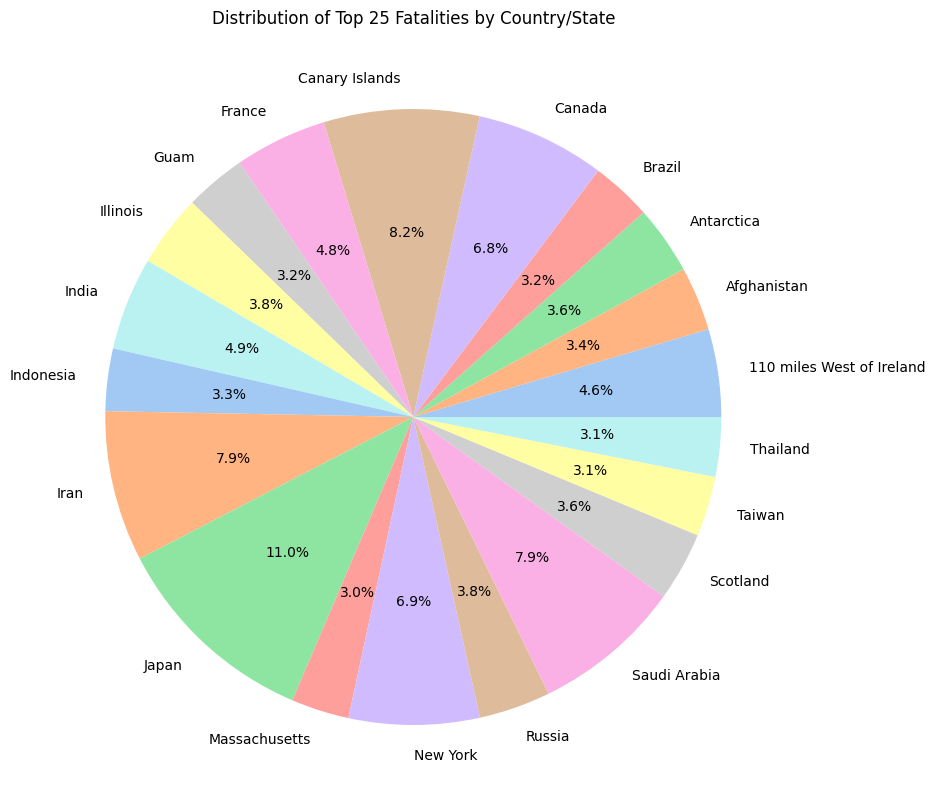

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

top_25 = top_100.head(25)

#Group by country/state incase it appears more than once in the top 5
pie_data = top_25.groupby('Country_State')['Fatalities'].sum()

plt.figure(figsize=(10, 10))
colors = sns.color_palette('pastel')[0:len(pie_data)]
plt.pie(pie_data, labels=pie_data.index, colors=colors, autopct='%1.1f%%')
plt.title('Distribution of Top 25 Fatalities by Country/State')
plt.show()